# 특성 공학과 규제

- 도메인: 생선의 길이, 높이, 너비를 활용하여 생선의 무게를 예측
- 목표: 라쏘 회귀를 사용하여 특성공학을 통해 활용된 특성을 확인한다.

<table align="left"><tr><td>
<a href="https://colab.research.google.com/github/rickiepark/hg-mldl2/blob/main/03-3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="코랩에서 실행하기"/></a>
</td></tr></table>

## 데이터 준비

In [1]:
import ssl
import pandas as pd
ssl._create_default_https_context = ssl._create_unverified_context

In [2]:
import pandas as pd

In [3]:
perch_full = pd.read_csv('http://bit.ly/perch_csv_data')
perch_full.head()

,length,height,width
0,8.4,2.11,1.41
1,13.7,3.53,2.00
2,15.0,3.82,2.43
3,16.2,4.59,2.63
4,17.4,4.59,2.94


In [4]:
import numpy as np

perch_weight = np.array(
    [5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0,
     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0,
     130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0,
     197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0,
     514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0,
     820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0,
     1000.0, 1000.0]
     )

In [5]:
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(perch_full, perch_weight, random_state=42)

## 사이킷런의 변환기

In [6]:
from sklearn.preprocessing import PolynomialFeatures

In [7]:
poly = PolynomialFeatures(include_bias=False)

poly.fit(train_input)
train_poly = poly.transform(train_input)

In [8]:
print(train_poly.shape)

(42, 9)


In [9]:
poly.get_feature_names_out()

array(['length', ' height', ' width', 'length^2', 'length  height',
       'length  width', ' height^2', ' height  width', ' width^2'],
      dtype=object)

In [10]:
test_poly = poly.transform(test_input)

## 규제

In [11]:
poly = PolynomialFeatures(degree=5, include_bias=False)

poly.fit(train_input)
train_poly = poly.transform(train_input)
test_poly = poly.transform(test_input)

In [12]:
print(train_poly.shape)

(42, 55)


In [13]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
ss.fit(train_poly)

train_scaled = ss.transform(train_poly)
test_scaled = ss.transform(test_poly)

## 라쏘

In [14]:
from sklearn.linear_model import Lasso

lasso = Lasso()
lasso.fit(train_scaled, train_target)
print(lasso.score(train_scaled, train_target))

0.989789897208096


In [15]:
print(lasso.score(test_scaled, test_target))

0.9800593698421884


In [16]:
train_score = []
test_score = []

alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]
for alpha in alpha_list:
    # 라쏘 모델을 만듭니다
    lasso = Lasso(alpha=alpha, max_iter=10000)
    # 라쏘 모델을 훈련합니다
    lasso.fit(train_scaled, train_target)
    # 훈련 점수와 테스트 점수를 저장합니다
    train_score.append(lasso.score(train_scaled, train_target))
    test_score.append(lasso.score(test_scaled, test_target))

c:\Users\tjdnr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.878e+04, tolerance: 5.183e+02
  model = cd_fast.enet_coordinate_descent(
c:\Users\tjdnr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.297e+04, tolerance: 5.183e+02
  model = cd_fast.enet_coordinate_descent(


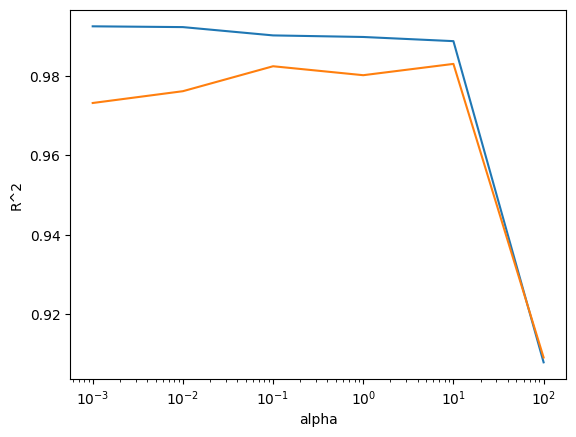

In [17]:
import matplotlib.pyplot as plt
plt.plot(alpha_list, train_score)
plt.plot(alpha_list, test_score)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('R^2')
plt.show()

In [18]:
lasso = Lasso(alpha=10)
lasso.fit(train_scaled, train_target)

print(lasso.score(train_scaled, train_target))
print(lasso.score(test_scaled, test_target))

0.9888067471131866
0.9824470598706695


In [19]:
print(np.sum(lasso.coef_ == 0))

40


In [20]:
used_count = np.sum(lasso.coef_ != 0)
print(f"사용된 특성의 개수: {used_count}")

사용된 특성의 개수: 15


In [21]:
feature_names = poly.get_feature_names_out()
used_features = feature_names[lasso.coef_ != 0]
print(f"사용된 특성: {used_features}")

사용된 특성: ['length^2' 'length  height' 'length  width' ' width^2' 'length^2  height'
 'length^2  width' 'length  height^2' 'length  height  width'
 'length  width^2' ' height  width^2' ' width^3' 'length  height^3'
 ' height^4' 'length  height^4' ' height^5']


라쏘 모델은 계수 값을 아예 0으로 만들 수 있다고 했던 것을 기억하나요? 라쏘 모델의 계수는 coef_ 속성에 저장되어 있습니다.

print(np.sum(lasso.coef_ == 0))

상기 코드는 계수가 0인 것의 갯수를 확인하는 코드입니다.

그렇다면 실제로 사용된 특성의 갯수는 몇개인가요?
그리고 특성공학에 의해 사용된 특성은 무엇인가요?

# Q1)아래에 코드셀을 추가하여 사용된 특성의 갯수를 확인할 수 있는 코드를 작성하세요.

# Q2)아래에 코드셀을 추가하여 특성공학에 의해 사용된 특성을 확인하는 코드를 작성하세요.